In [0]:
storage_account_name = "amazondatalake60305750"
storage_account_key = "g3s7XzjvHXE0nuPEy/I0YsC/aYBtO5VNpfnFUYIZ27XayLbZ7VDVfTgFlscoZ90mlz6JY60BzQ3j+AStxoNjUw=="

spark.conf.set(
    f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
    storage_account_key
)

In [0]:
gold_path = f"abfss://curated@{storage_account_name}.dfs.core.windows.net/features_v1/"
df = spark.read.parquet(gold_path)

print("Rows:", df.count())
print("Cols:", len(df.columns))
df.printSchema()

Rows: 1687427
Cols: 11
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



In [0]:
from pyspark.sql.functions import col, count, when, isnan

# Check for nulls in key columns
df.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in ['reviewText', 'overall', 'asin', 'reviewerID']
]).show()

+----------+-------+----+----------+
|reviewText|overall|asin|reviewerID|
+----------+-------+----+----------+
|         0|      0|   0|         0|
+----------+-------+----+----------+



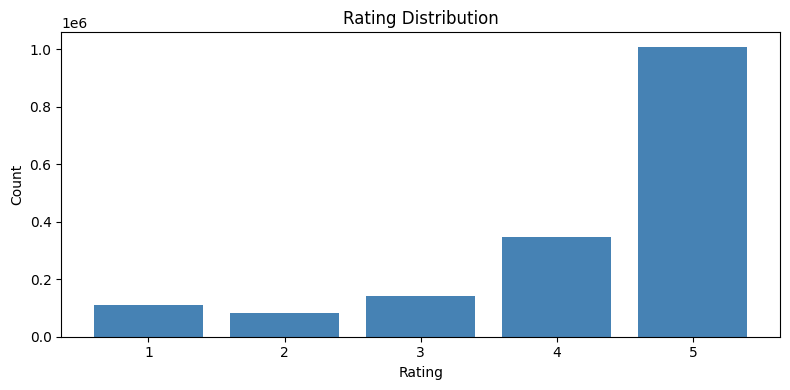

Rating distribution matters for feature engineering because class imbalance
(e.g. too many 5-stars) can bias sentiment thresholds and TF-IDF weights.


In [0]:
# Rating distribution
rating_dist = df.groupBy("overall").count().orderBy("overall").toPandas()

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.bar(rating_dist['overall'], rating_dist['count'], color='steelblue')
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.tight_layout()
plt.show()

print("Rating distribution matters for feature engineering because class imbalance")
print("(e.g. too many 5-stars) can bias sentiment thresholds and TF-IDF weights.")

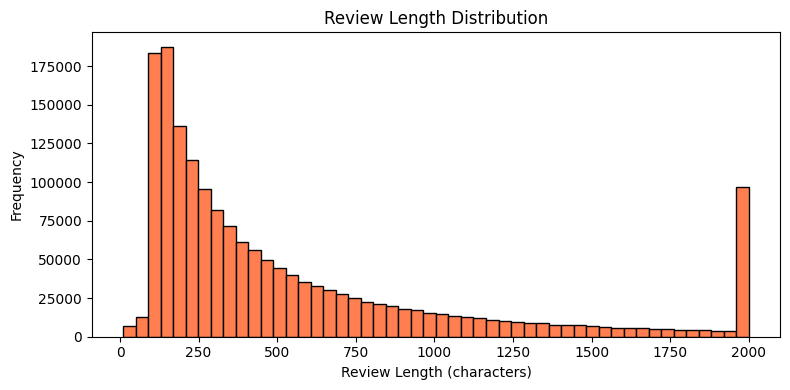


Why this matters for feature engineering:
Most reviews are short. Very short reviews carry less signal for TF-IDF.
review_length_chars and review_length_words will be informative ML features.


In [0]:
from pyspark.sql.functions import length

# Review length distribution
length_df = df.withColumn("review_len", length(col("reviewText"))) \
              .select("review_len").toPandas()

plt.figure(figsize=(8,4))
plt.hist(length_df['review_len'].clip(0, 2000), bins=50, color='coral', edgecolor='black')
plt.xlabel("Review Length (characters)")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.tight_layout()
plt.show()

print("\nWhy this matters for feature engineering:")
print("Most reviews are short. Very short reviews carry less signal for TF-IDF.")
print("review_length_chars and review_length_words will be informative ML features.")

In [0]:
from pyspark.sql.functions import col, count

# Drift-resistant sampling: stratified by review_year
# This ensures temporal distribution is preserved across years
total = df.count()
sample_n = 300_000

# Calculate fraction per year proportionally
year_counts = df.groupBy("review_year").count().collect()
fractions = {row['review_year']: min(sample_n / total * 1.2, 1.0) for row in year_counts}

df_sampled = df.sampleBy("review_year", fractions, seed=42)

# Trim to exactly 300k if over
if df_sampled.count() > sample_n:
    df_sampled = df_sampled.limit(sample_n)

print("Sampled rows:", df_sampled.count())
print("Sampled cols:", len(df_sampled.columns))

Sampled rows: 300000
Sampled cols: 11


In [0]:
# Sanity check - compare rating distributions
print("=== ORIGINAL ===")
df.groupBy("overall").count().orderBy("overall").show()

print("=== SAMPLED ===")
df_sampled.groupBy("overall").count().orderBy("overall").show()

=== ORIGINAL ===
+-------+-------+
|overall|  count|
+-------+-------+
|    1.0| 108612|
|    2.0|  82056|
|    3.0| 142106|
|    4.0| 346693|
|    5.0|1007960|
+-------+-------+

=== SAMPLED ===
+-------+------+
|overall| count|
+-------+------+
|    1.0| 19256|
|    2.0| 14636|
|    3.0| 25270|
|    4.0| 61424|
|    5.0|179414|
+-------+------+



In [0]:
sampled_gold_path = (
    f"abfss://curated@{storage_account_name}.dfs.core.windows.net/features_v1_sampled/"
)

df_sampled.write \
    .mode("overwrite") \
    .parquet(sampled_gold_path)

print("Written successfully to:", sampled_gold_path)

Written successfully to: abfss://curated@amazondatalake60305750.dfs.core.windows.net/features_v1_sampled/
